In [ ]:
from pathlib import Path
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

dataDir = Path("data")
csvFile = dataDir / "pp-2020.csv"


columns = [
    "transaction_id",
    "price",
    "date_of_transfer",
    "postcode",
    "property_type",
    "new_build",
    "duration",
    "paon",
    "saon",
    "street",
    "locality",
    "town_city",
    "district",
    "county",
    "ppd_category",
    "record_status",
]

allYears = pd.read_csv(csvFile, header=None, names=columns)

# Clean types
allYears["date_of_transfer"] = pd.to_datetime(allYears["date_of_transfer"])
allYears["price"] = pd.to_numeric(allYears["price"])

In [2]:
allYears.shape

(896568, 16)

In [3]:
allYears.isna().sum().sort_values(ascending=False).head()

saon             783065
locality         545171
street            18035
postcode           3277
property_type         0
dtype: int64

In [4]:
allYears.describe()

,price,date_of_transfer
count,8.965680e+05,896568
mean,3.777048e+05,2020-07-24 20:36:38.720453888
min,1.000000e+00,2020-01-01 00:00:00
25%,1.575000e+05,2020-04-03 00:00:00
50%,2.499950e+05,2020-08-14 00:00:00
75%,3.850000e+05,2020-10-30 00:00:00
max,4.000000e+08,2020-12-31 00:00:00
std,1.712974e+06,NaN


In [5]:
cleanData = allYears[allYears["ppd_category"] == "A"].copy()
# Drop 90% of the dataset to preserve memory
cleanData = (
    cleanData
    .groupby("property_type", group_keys=False)
    .apply(lambda x: x.sample(frac=0.10, random_state=42))
)


/tmp/ipykernel_5808/359420341.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.10, random_state=42))


In [6]:
columnsToDrop = [
    "transaction_id",
    "paon",
    "saon",
    "street",
    "locality",
    "record_status",
    "county",
    "ppd_category"
]

cleanData.drop(columns=columnsToDrop, inplace=True)

In [7]:
cleanData.isna().sum().sort_values(ascending=False).head()

postcode            9
price               0
date_of_transfer    0
property_type       0
new_build           0
dtype: int64

In [8]:
cleanData.describe()

,price,date_of_transfer
count,7.524700e+04,75247
mean,3.287208e+05,2020-07-26 08:41:41.585445120
min,7.500000e+02,2020-01-01 00:00:00
25%,1.690000e+05,2020-04-08 00:00:00
50%,2.580000e+05,2020-08-18 00:00:00
75%,3.900000e+05,2020-10-30 00:00:00
max,3.550000e+07,2020-12-31 00:00:00
std,3.664898e+05,NaN


In [9]:
cleanData = cleanData.dropna(subset=["postcode"])

In [10]:
cleanData.isna().sum().sort_values(ascending=False).head()

price               0
date_of_transfer    0
postcode            0
property_type       0
new_build           0
dtype: int64

In [11]:
cleanData = cleanData[(cleanData["price"] >= 90_000) & (cleanData["price"] <= 5_000_000)]

In [12]:
cleanData.describe()

,price,date_of_transfer
count,7.158900e+04,71589
mean,3.371763e+05,2020-07-27 09:21:06.177764608
min,9.000000e+04,2020-01-01 00:00:00
25%,1.800000e+05,2020-04-09 00:00:00
50%,2.680000e+05,2020-08-20 00:00:00
75%,4.000000e+05,2020-10-30 00:00:00
max,5.000000e+06,2020-12-31 00:00:00
std,2.769762e+05,NaN


In [13]:
cleanData["year"] = cleanData["date_of_transfer"].dt.year
cleanData["month"] = cleanData["date_of_transfer"].dt.month
cleanData = cleanData.drop(columns="date_of_transfer")

In [14]:
cleanData["postcode"] = cleanData["postcode"].str.split().str[0]

In [15]:
cleanData.head()

,price,postcode,property_type,new_build,duration,town_city,district,year,month
2437,300000,PE15,D,Y,F,MARCH,FENLAND,2020,4
415936,447500,PE19,D,N,F,ST NEOTS,HUNTINGDONSHIRE,2020,12
749525,255000,TR2,D,N,F,TRURO,CORNWALL,2020,11
551195,210000,DN16,D,N,F,SCUNTHORPE,NORTH LINCOLNSHIRE,2020,3
358729,785000,RH2,D,N,F,REIGATE,REIGATE AND BANSTEAD,2020,1


In [16]:
categoricalColumns = [
    "property_type",
    "new_build",
    "duration",
    "postcode",
    "town_city",
    "district",
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded = encoder.fit_transform(cleanData[categoricalColumns])

encodedData = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categoricalColumns),
    index=cleanData.index
)

cleanData = pd.concat(
    [cleanData.drop(columns=categoricalColumns), encodedData],
    axis=1
)

In [17]:
target = "price"

X = cleanData.drop(columns=[target])
y = cleanData[target]

In [18]:
XTrain, XTest, yTrain, yTest = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

XTrain.shape, XTest.shape

((57271, 3703), (14318, 3703))

In [19]:
linReg = LinearRegression()
linReg.fit(XTrain, yTrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
yPred = linReg.predict(XTest)
yPred[:10]

array([393135.974801  , 198547.74685519, 317918.6843134 , 259899.14683602,
       377243.08773523, 298522.89579708, 252301.04599826, 369471.30378218,
       362760.47173768,  73471.26707957])

In [21]:
mae = mean_absolute_error(yTest, yPred)
rmse = mean_squared_error(yTest, yPred) ** 0.5
r2 = r2_score(yTest, yPred)

print(f"MAE:  £{mae:,.0f}")
print(f"RMSE: £{rmse:,.0f}")
print(f"R²:   {r2:.3f}")


MAE:  £102,853
RMSE: £191,051
R²:   0.511


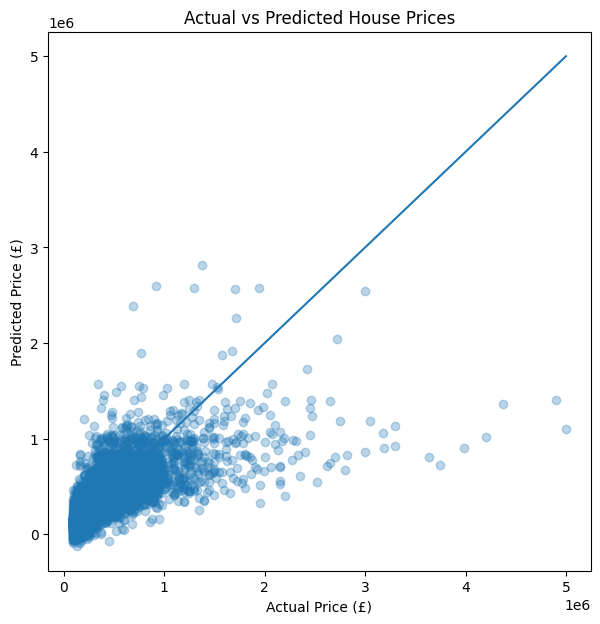

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 7))
plt.scatter(yTest, yPred, alpha=0.3)
plt.plot(
    [yTest.min(), yTest.max()],
    [yTest.min(), yTest.max()]
)
plt.xlabel("Actual Price (£)")
plt.ylabel("Predicted Price (£)")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [ ]:
futureXSemi = pd.DataFrame(0, index=[0], columns=X.columns)
futureXSemi.loc[0, "year"] = 2026
futureXSemi.loc[0, "month"] = 8
futureXSemi.loc[0, "property_type_S"] = 1
futureXSemi.loc[0, "new_build_Y"] = 0
futureXSemi.loc[0, "duration_F"] = 1
futureXSemi.loc[0, "postcode_area_B15"] = 1